In [21]:
import torch

from src import model as models

## importamos los dataloaders
from src.datadogs import dog_train_loader, dog_test_loader

from src.utils import probar_modelo, comparar_modelos, calculo_perdida

from src.train import train_ae, train_metanca


In [22]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

## para que los cambios en los files se apliquen sin reiniciar kernels
%load_ext autoreload
%autoreload 2

Usando el dispositivo: cuda
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
## parametros para probar entrenamiento autoencoder

params_encoder_old = {
    'in_c': 3,
    # --- ENCODER ---
    'Conv2DParams1': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    'Conv2DParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    
    # Pass-through debe terminar con 128 canales y stride total de 2 para sumar con Conv2DParams2
    'PassThroughParams1': {'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'PassThroughParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    'Conv2DParams3': {'out_c': 256, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.2},

    # --- DECODER ---
    'Conv2DTransposeParams3': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'Conv2DTransposeParams2': {'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # MixParams recibe d2_out (64) + c1_out (64), mantiene 64 canales
    'MixParams': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                  'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # Salida final: 3 canales para las 3 clases del dataset
    'Conv2DTransposeParams1': {'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                               'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0}
}

In [24]:
params_encoder2 = {
    'in_c': 3,
    
    # Encoder
    # Conv1 define el canal de nuestro skip_out de alta resolución. 
    # Bajamos a 32 canales para balancear la carga computacional.
    'Conv2DParams1': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Conv2 comprime el espacio (/2) y sube canales. Terminamos con 64 canales.
    'Conv2DParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (64 canales y stride total de 2)
    'PassThroughParams1': {
        'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Aquí colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': 16, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1
    },

    # Decoder
    # TransConv3 procesa el latente del NCA (16 canales) y recupera la resolución espacial (*2).
    # Lo subimos a 64 canales para ir preparando el terreno de la mezcla.
    'Conv2DTransposeParams3': {
        'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con 32 canales para coincidir con los 32 canales de 'Conv2DParams1' (skip_out).
    'Conv2DTransposeParams2': {
        'out_c': 32, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # MixParams recibe la suma directa de d2_out (32) + c1_out (32).
    # Procesa la combinación manteniendo 32 canales para refinar bordes antes de clasificar.
    'MixParams': {
        'out_c': 32, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0
    },
    
    # Salida final del Decoder: Proyecta los 32 canales a los 3 canales del trimapa (fondo, interior, borde)
    'Conv2DTransposeParams1': {
        'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
        'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0
    }
}

##con estos parametros el espacio se colapsa a 1/4 de la resolución original, con 16 canales en el latente para los nca

In [27]:
### USados en V1
# =========================================================================
# 🎛️ DEFINICIÓN DE VARIABLES COMUNES (HIPERPARÁMETROS ARQUITECTÓNICOS)
# =========================================================================

# 1. Configuración de Canales (Flujo Simétrico de Dimensiones)
CHANNELS_IN       = 3   # Imágenes RGB de entrada
CHANNELS_LEVEL_1  = 32  # Resolución alta (Skip Connection c1_out / d2_out)
CHANNELS_LEVEL_2  = 64  # Resolución intermedia (Salida de compresión y Pass-Through)
CHANNELS_LATENT   = 64  # Cuello de botella latente (Espacio del ADN / Entrada del NCA)
CHANNELS_OUT      = 3   # Clases del Trimapa (Fondo, Interior, Contorno)

# 2. Parámetros de Convolución Estándar
KERNEL_STD        = 3
STRIDE_NORMAL     = 1
STRIDE_COMPRESS   = 2
PADDING_STD       = 1

# 3. Regularización y Normalización
DROPOUT_ENCODER   = 0.1
DROPOUT_DECODER   = 0.0
ACT_RELU          = 'relu'
ACT_NONE          = None

# =========================================================================
# 📐 DICCIONARIO DE PARÁMETROS CONFIGURADO CON VARIABLES COMUNES
# =========================================================================

params_encoder3 = {
    'in_c': CHANNELS_IN,
    
    # ─── ENCODER ──────────────────────────────────────────────────────────
    # Conv1 define el canal de nuestro skip_out de alta resolución.
    'Conv2DParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Conv2 comprime el espacio (/2) y sube canales.
    'Conv2DParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (Canales e impacto de Stride)
    'PassThroughParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': 1, 
        'strides': STRIDE_NORMAL, 
        'padding': 0, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': CHANNELS_LATENT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },

    # ─── DECODER ──────────────────────────────────────────────────────────
    # TransConv3 procesa el latente del NCA y recupera la resolución espacial (*2).
    'Conv2DTransposeParams3': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con los mismos canales del skip_out (CHANNELS_LEVEL_1).
    'Conv2DTransposeParams2': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # MixParams recibe la suma directa de d2_out + c1_out. Procesa la combinación manteniendo el ancho.
    'MixParams': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # Salida final del Decoder: Proyecta los canales refinados a los canales del trimapa.
    'Conv2DTransposeParams1': {
        'out_c': CHANNELS_OUT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_NONE, 
        'batch_normalization': False, 
        'dropout_rate': DROPOUT_DECODER
    }
}

In [8]:
ae_model = models.AutoEncoderDown3(params_encoder3).to(device)

In [45]:
ae_model.load_state_dict(torch.load("ae_fase2.1_checkpoint_ep10.pth", map_location=device))

<All keys matched successfully>

Loss en el batch de prueba (dice): 0.6781


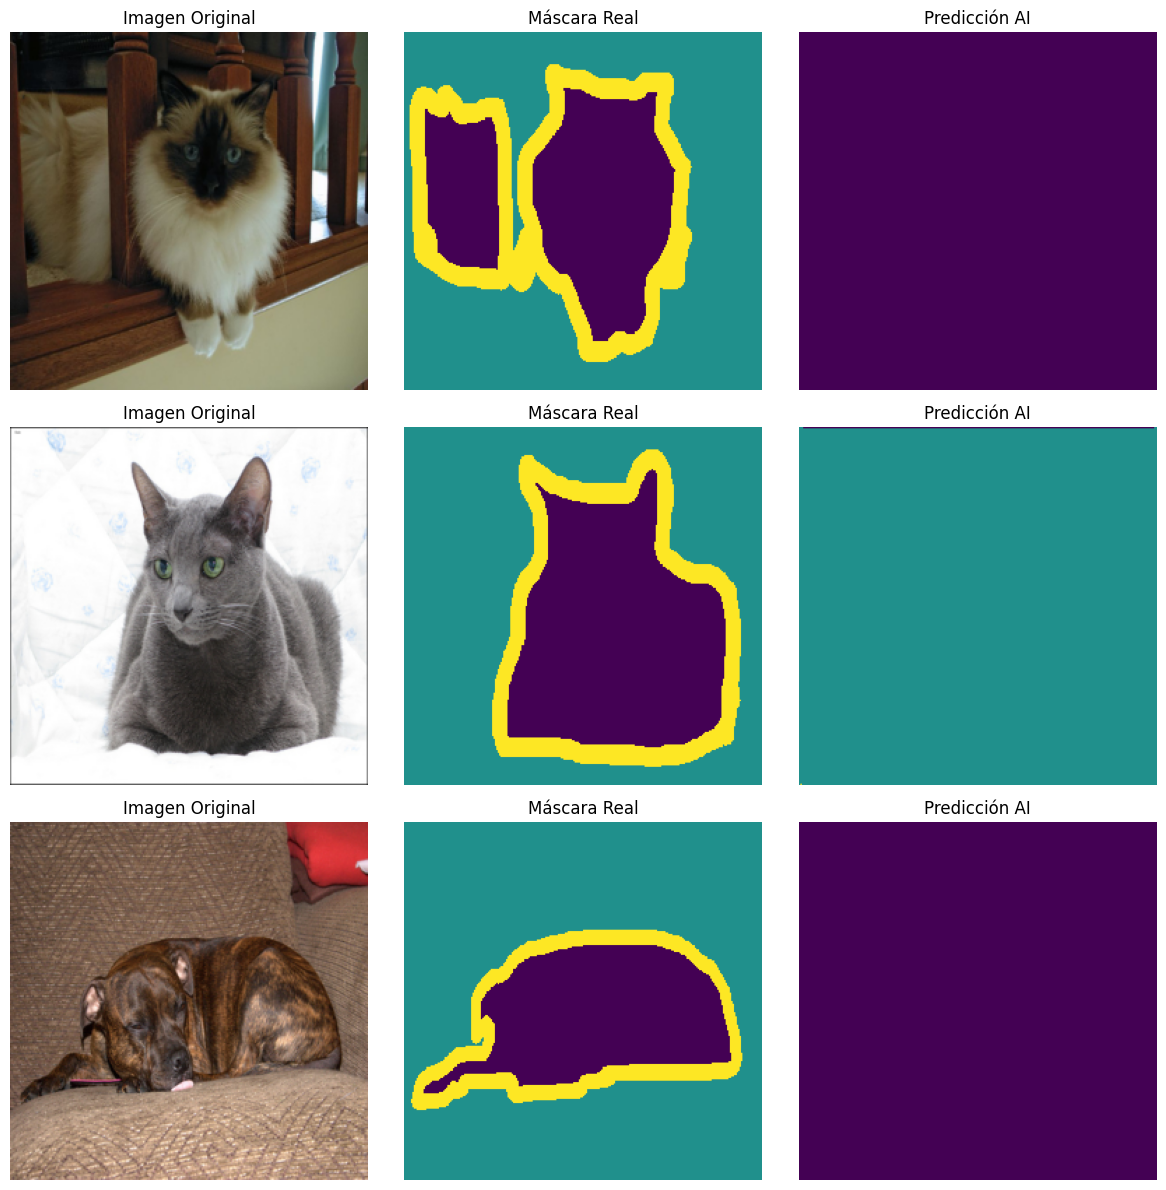

In [52]:
probar_modelo(ae_model, dog_test_loader, device)

In [28]:
meta_nca = models.MetaNCASegmenter(ae_params=params_encoder3, nca_steps=16).to(device)


In [29]:
meta_nca.load_state_dict(torch.load("metancav3.fase2_checkpoint_ep13.pth", map_location=device))

<All keys matched successfully>

In [30]:
meta_nca.nca_steps

16

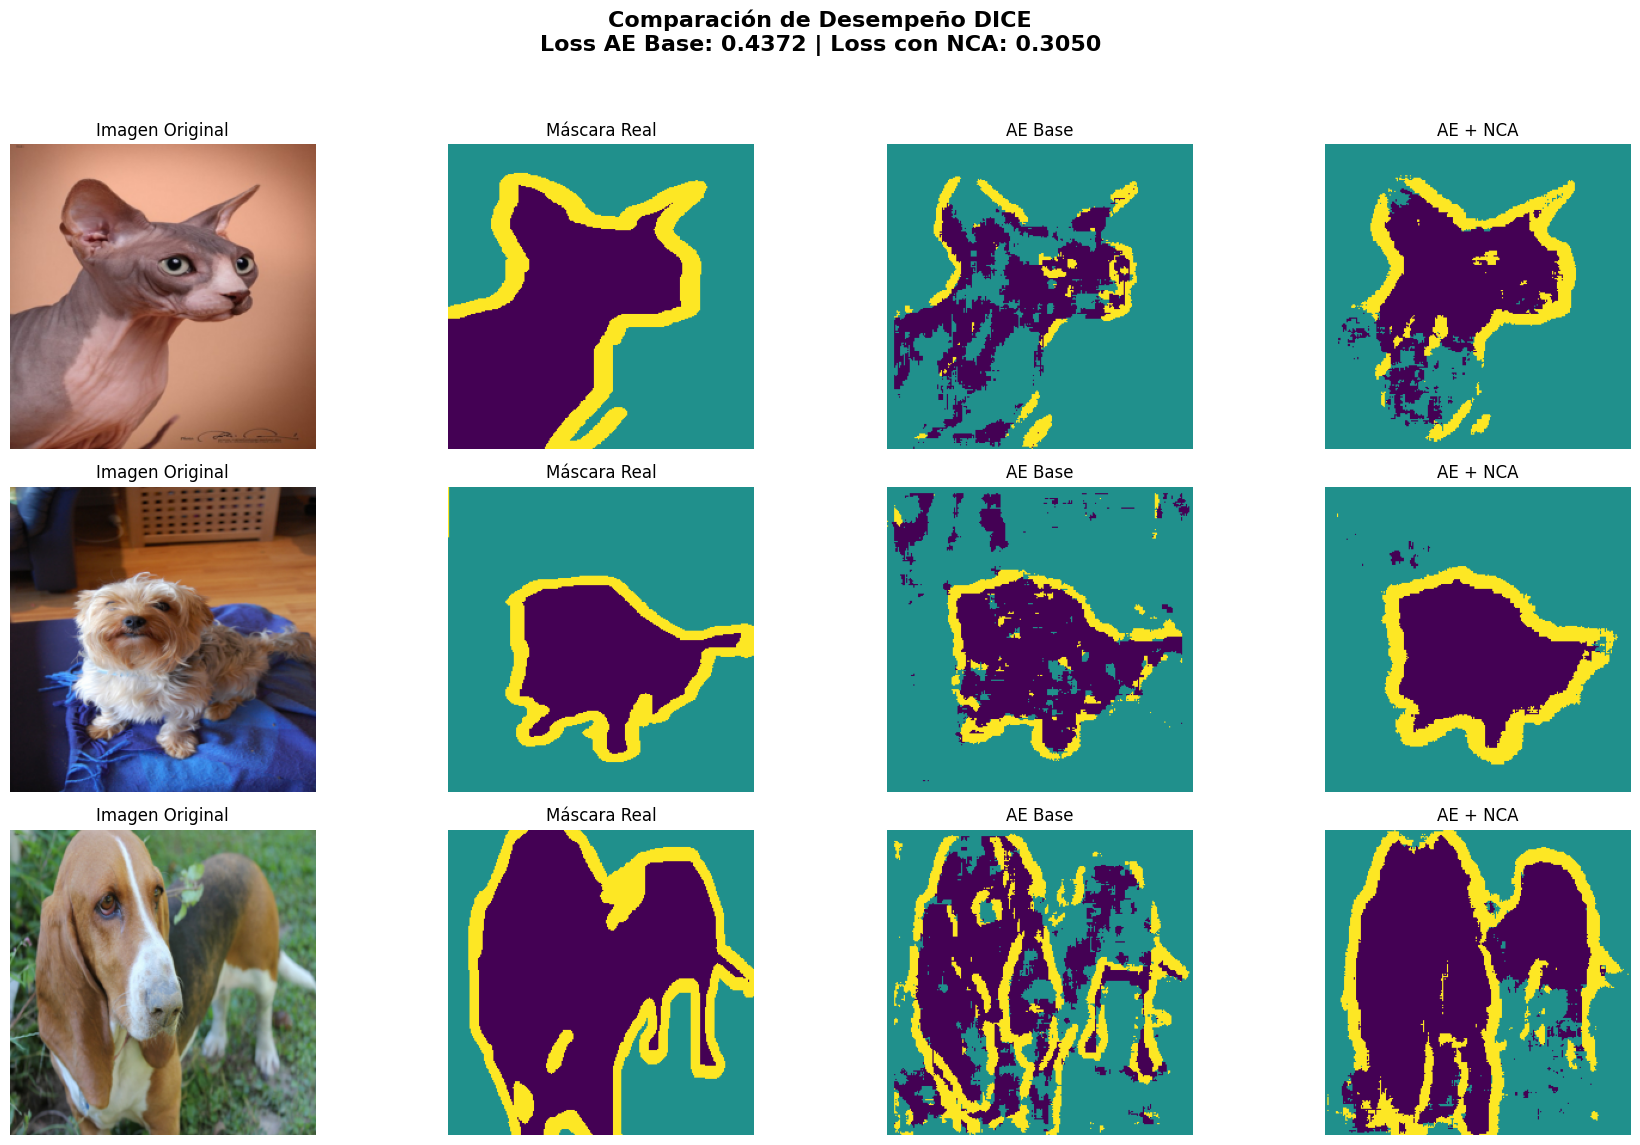

In [42]:
meta_nca.nca_steps = 32
comparar_modelos(meta_nca.ae, meta_nca, dog_test_loader, device)

### Coeficiente de Dice Multiclase Utilizado

Para evaluar el solapamiento global en todas las categorías de forma simultánea, se calcula el promedio simple sobre el conjunto de clases $C$:

$$\text{Dice Score} = \frac{1}{|C|} \sum_{c \in C} \frac{2 \sum_{i} p_{ic} g_{ic} + \epsilon}{\sum_{i} p_{ic}^2 + \sum_{i} g_{ic}^2 + \epsilon}$$

Donde la función de pérdida (**Dice Loss**) que el optimizador minimiza es el complemento a uno del puntaje:

$$\text{Dice Loss} = 1 - \text{Dice Score}$$

**Donde:**
* $|C|$: Número total de clases del trimapa ($|C| = 3$: Fondo, Contorno e Interior).
* $i$: Índice del píxel dentro de la grilla espacial $H \times W$.
* $p_{ic}$: Probabilidad predicha por el Decoder (vía Softmax) para el píxel $i$ en la clase $c$.
* $g_{ic}$: Valor binario real (*Ground Truth*) en formato One-Hot para el píxel $i$ en la clase $c$.
* $\epsilon$: Factor de suavizado numérico ($10^{-6}$) para prevenir divisiones por cero e indeterminaciones $\frac{0}{0}$.

In [114]:
# perdidas com metricas, 32 steps del NCA, en el test set
meta_nca.nca_steps = 32

dice = calculo_perdida(meta_nca, dog_test_loader, device, perdida="dice")

cross_entropy = calculo_perdida(meta_nca, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss Meta-NCA, 32 steps: {dice:.4f}")
print(f"Cross-Entropy Loss Meta-NCA, 32 steps: {cross_entropy:.4f}")

Dice Loss Meta-NCA, 32 steps: 0.3653
Cross-Entropy Loss Meta-NCA, 32 steps: 0.5028


In [113]:
# perdidas com metricas, 64 steps del NCA, en el test set

meta_nca.nca_steps = 64

dice_64 = calculo_perdida(meta_nca, dog_test_loader, device, perdida="dice")

cross_entropy_64 = calculo_perdida(meta_nca, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss Meta-NCA, 64 steps: {dice_64:.4f}")
print(f"Cross-Entropy Loss Meta-NCA, 64 steps: {cross_entropy_64:.4f}")

Dice Loss Meta-NCA, 64 steps: 0.3443
Cross-Entropy Loss Meta-NCA, 64 steps: 0.4763


In [109]:
dice_ae = calculo_perdida(ae_model, dog_test_loader, device, perdida="dice")

cross_entropy_ae = calculo_perdida(ae_model, dog_test_loader, device, perdida="cross_entropy")

print(f"Dice Loss ae solo: {dice_ae:.4f}")
print(f"Cross-Entropy Loss ae solo: {cross_entropy_ae:.4f}")

Dice Loss ae solo: 0.4610
Cross-Entropy Loss ae solo: 0.6389


# Pruebas:

## Style Transfer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. CONFIGURACIÓN Y CARGA DE MODELOS (Ajusta los nombres de tus archivos)
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos tu modelo completo de la Fase 2
# (Asegúrate de que 'params_encoder2' esté definido en tu notebook)
metanca_model = models.MetaNCASegmenter(
    ae_params=params_encoder2, 
    nca_steps=32, 
    nca_hidden_dims=64
).to(device)

# Cargamos los pesos definitivos de la Fase 2 que entrenaste anoche
metanca_model.load_state_dict(torch.load("metancav5.fase2_checkpoint_ep4.pth", map_location=device))
metanca_model.eval() # Modo evaluación estricto

print("🚀 Modelos cargados y listos en:", device)

# =====================================================================
# 2. SELECCIÓN DE LAS MASCOTAS DE PRUEBA (Mascota A y Mascota B)
# =====================================================================
# Tomamos un lote del test loader para elegir dos imágenes distintas
images_test, masks_test = next(iter(dog_test_loader))

img_A = images_test[0:1].to(device) # Mascota A (ej: Perro grande)
img_B = images_test[1:2].to(device) # Mascota B (ej: Perro chico)

# =====================================================================
# 3. EXTRACCIÓN DE SUS "ADN" GEOMÉTRICOS (Forward del Encoder congelado)
# =====================================================================
with torch.no_grad():
    # Mascota A
    c1_A = metanca_model.ae.conv_layer_1(img_A)
    c2_A = metanca_model.ae.conv_layer_2(c1_A)
    p2_A = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_A))
    latent_A = metanca_model.ae.conv_layer_3(c2_A + p2_A)
    dna_A = latent_A.mean(dim=[2, 3]) # Vector de ADN (1, canales_latentes)

    # Mascota B
    c1_B = metanca_model.ae.conv_layer_1(img_B)
    c2_B = metanca_model.ae.conv_layer_2(c1_B)
    p2_B = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_B))
    latent_B = metanca_model.ae.conv_layer_3(c2_B + p2_B)
    dna_B = latent_B.mean(dim=[2, 3])

# =====================================================================
# 4. INTERPOLACIÓN LATENTE Y SIMULACIÓN DEL NCA
# =====================================================================
# Definimos los pasos de alfa (de 0.0 que es 100% Mascota A, a 1.0 que es 100% Mascota B)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
steps_evaluacion = 24 # Pasos fijos para que el autómata celular estabilice la forma

fig, axes = plt.subplots(1, len(alphas), figsize=(18, 4))
fig.suptitle("Morfogénesis Cruzada: Interpolación en el Manifold Convexo del NCA", fontsize=14, fontweight='bold')

print("🔮 Ejecutando transiciones moleculares en el autómata...")

for idx, alpha in enumerate(alphas):
    with torch.no_grad():
        # Interpolación lineal matemática en el espacio de fases
        dna_interp = (1.0 - alpha) * dna_A + alpha * dna_B
        latent_base_interp = (1.0 - alpha) * latent_A + alpha * latent_B
        c1_interp = (1.0 - alpha) * c1_A + alpha * c1_B
        
        # La HyperNetwork predice las nuevas leyes físicas para esta combinación híbrida
        dynamic_weights_interp = metanca_model.param_predictor(dna_interp)
        
        # El NCA evoluciona el estado latente mezclado usando las leyes mezcladas
        latent_evolved = metanca_model.nca(latent_base_interp, weights=dynamic_weights_interp, steps=steps_evaluacion)
        
        # El Decoder proyecta el resultado final al Trimapa
        d3_out = metanca_model.ae.trans_conv_3(latent_evolved)
        d2_out = metanca_model.ae.trans_conv_2(d3_out)
        mixed = metanca_model.ae.mix_layer(d2_out + c1_interp)
        outputs = metanca_model.ae.trans_conv_1(mixed)
        
        # Convertimos los logits del trimapa a clases (0, 1, 2) para visualizar
        pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()
        
    # Graficamos en la celda de Jupyter
    ax = axes[idx]
    ax.imshow(pred_mask, cmap='viridis') # Puedes usar 'tab10' o tu mapa de color de trimapas
    ax.set_title(f"$\\alpha$ = {alpha:.2f}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()import torch
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. CONFIGURACIÓN Y CARGA DE MODELOS (Ajusta los nombres de tus archivos)
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos tu modelo completo de la Fase 2
# (Asegúrate de que 'params_encoder2' esté definido en tu notebook)
metanca_model = models.MetaNCASegmenter(
    ae_params=params_encoder2, 
    nca_steps=32, 
    nca_hidden_dims=64
).to(device)

# Cargamos los pesos definitivos de la Fase 2 que entrenaste anoche
metanca_model.load_state_dict(torch.load("metancav5.fase2_checkpoint_ep4.pth", map_location=device))
metanca_model.eval() # Modo evaluación estricto

print("🚀 Modelos cargados y listos en:", device)

# =====================================================================
# 2. SELECCIÓN DE LAS MASCOTAS DE PRUEBA (Mascota A y Mascota B)
# =====================================================================
# Tomamos un lote del test loader para elegir dos imágenes distintas
images_test, masks_test = next(iter(dog_test_loader))

img_A = images_test[0:1].to(device) # Mascota A (ej: Perro grande)
img_B = images_test[1:2].to(device) # Mascota B (ej: Perro chico)

# =====================================================================
# 3. EXTRACCIÓN DE SUS "ADN" GEOMÉTRICOS (Forward del Encoder congelado)
# =====================================================================
with torch.no_grad():
    # Mascota A
    c1_A = metanca_model.ae.conv_layer_1(img_A)
    c2_A = metanca_model.ae.conv_layer_2(c1_A)
    p2_A = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_A))
    latent_A = metanca_model.ae.conv_layer_3(c2_A + p2_A)
    dna_A = latent_A.mean(dim=[2, 3]) # Vector de ADN (1, canales_latentes)

    # Mascota B
    c1_B = metanca_model.ae.conv_layer_1(img_B)
    c2_B = metanca_model.ae.conv_layer_2(c1_B)
    p2_B = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_B))
    latent_B = metanca_model.ae.conv_layer_3(c2_B + p2_B)
    dna_B = latent_B.mean(dim=[2, 3])

# =====================================================================
# 4. INTERPOLACIÓN LATENTE Y SIMULACIÓN DEL NCA
# =====================================================================
# Definimos los pasos de alfa (de 0.0 que es 100% Mascota A, a 1.0 que es 100% Mascota B)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
steps_evaluacion = 24 # Pasos fijos para que el autómata celular estabilice la forma

fig, axes = plt.subplots(1, len(alphas), figsize=(18, 4))
fig.suptitle("Morfogénesis Cruzada: Interpolación en el Manifold Convexo del NCA", fontsize=14, fontweight='bold')

print("🔮 Ejecutando transiciones moleculares en el autómata...")

for idx, alpha in enumerate(alphas):
    with torch.no_grad():
        # Interpolación lineal matemática en el espacio de fases
        dna_interp = (1.0 - alpha) * dna_A + alpha * dna_B
        latent_base_interp = (1.0 - alpha) * latent_A + alpha * latent_B
        c1_interp = (1.0 - alpha) * c1_A + alpha * c1_B
        
        # La HyperNetwork predice las nuevas leyes físicas para esta combinación híbrida
        dynamic_weights_interp = metanca_model.param_predictor(dna_interp)
        
        # El NCA evoluciona el estado latente mezclado usando las leyes mezcladas
        latent_evolved = metanca_model.nca(latent_base_interp, weights=dynamic_weights_interp, steps=steps_evaluacion)
        
        # El Decoder proyecta el resultado final al Trimapa
        d3_out = metanca_model.ae.trans_conv_3(latent_evolved)
        d2_out = metanca_model.ae.trans_conv_2(d3_out)
        mixed = metanca_model.ae.mix_layer(d2_out + c1_interp)
        outputs = metanca_model.ae.trans_conv_1(mixed)
        
        # Convertimos los logits del trimapa a clases (0, 1, 2) para visualizar
        pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()
        
    # Graficamos en la celda de Jupyter
    ax = axes[idx]
    ax.imshow(pred_mask, cmap='viridis') # Puedes usar 'tab10' o tu mapa de color de trimapas
    ax.set_title(f"$\\alpha$ = {alpha:.2f}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

Aca vemos si la transicion de una adn a otro, interpolamos estos con a través de una combinación convexa. Si la transición es "smooth" es indicio de que el espacio latente es cotinuo y convexo y que el parameter predictor no esta memorizando. 